In [20]:
import pylab as plt
import numpy as np
from scipy.ndimage import gaussian_filter, label, find_objects

In [28]:
#H,W = 4096, 4096
H,W = 20_000, 20_000

In [29]:
sig1 = 1.
image = np.random.normal(size=(H,W)) * sig1
image_sn = image / sig1

In [46]:
psf_sigma = 2.
psf_norm = 1./(2. * np.sqrt(np.pi) * psf_sigma)
det_img = gaussian_filter(image, psf_sigma) / psf_norm**2
det_sig1 = sig1 / psf_norm
det_sn = det_img / det_sig1
psf_fwhm = psf_sigma * 2.35
pixscale = 0.2
print('Assumed PSF FWHM: %.1f pixels or seeing = %.2f arcsec' % (psf_fwhm, psf_fwhm * pixscale))

Assumed PSF FWHM: 4.7 pixels or seeing = 0.94 arcsec


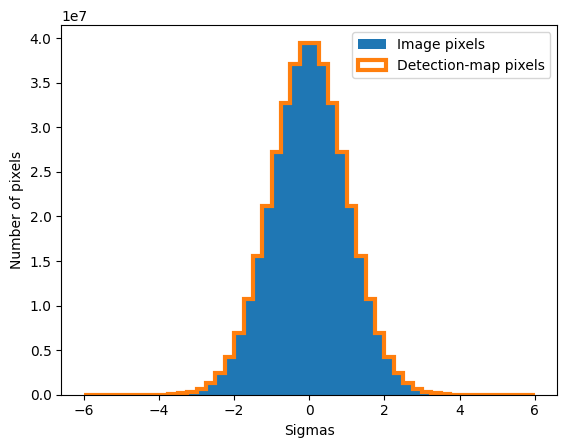

In [38]:
plt.hist(image_sn.ravel(), range=(-6, +6), bins=48, label='Image pixels')
plt.hist(det_sn.ravel(), range=(-6, +6), bins=48, histtype='step', lw=3, label='Detection-map pixels')
plt.xlabel('Sigmas')
plt.ylabel('Number of pixels')
plt.legend();
plt.savefig('hist.png')

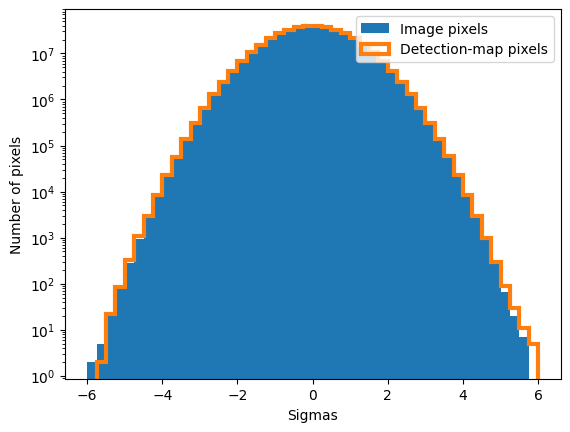

In [40]:
plt.hist(image_sn.ravel(), range=(-6, +6), bins=48, log=True, label='Image pixels');
plt.hist(det_sn.ravel(), range=(-6, +6), bins=48, histtype='step', log=True, lw=3, label='Detection-map pixels');
plt.xlabel('Sigmas')
plt.ylabel('Number of pixels')
plt.legend();
plt.savefig('hist-log.png')

In [41]:
nhot_img = np.sum(image_sn > 5.)
nhot_det = np.sum(det_sn > 5.)
print('Number of image pixels     > 5 sigma:', nhot_img)
print('Number of detection pixels > 5 sigma:', nhot_det)

Number of image pixels     > 5 sigma: 94
Number of detection pixels > 5 sigma: 135


In [42]:
label_img, nblobs_img = label(image_sn > 5.)
label_det, nblobs_det = label(det_sn > 5.)
print('Number of image blobs     > 5 sigma:', nblobs_img)
print('Number of detection blobs > 5 sigma:', nblobs_det)

Number of image blobs     > 5 sigma: 94
Number of detection blobs > 5 sigma: 47


In [44]:
nlsst_img = 189 * 4096 * 4096 * nblobs_img / (H*W)
nlsst_det = 189 * 4096 * 4096 * nblobs_det / (H*W)
print('Number of image blobs     > 5 sigma predicted per LSST exposure: %.1f' % nlsst_img)
print('Number of detection blobs > 5 sigma predicted per LSST exposure: %.1f' % nlsst_det)

Number of image blobs     > 5 sigma predicted per LSST exposure: 745.2
Number of detection blobs > 5 sigma predicted per LSST exposure: 372.6
